<a href="https://colab.research.google.com/github/shikhachourey1992/Mateplotlib/blob/main/Dropout_BatchNormaliztion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay


In [ ]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()
print(x_train.shape)
print(y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)


In [ ]:
x_train=x_train/255.0
y_train=y_train/255.0

TypeError: list indices must be integers or slices, not numpy.float64

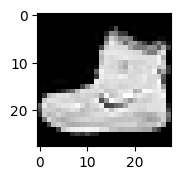

In [ ]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i],cmap='gray')
  plt.title(classes[y_train[i]])
  plt.axis('off')
plt.show()


In [ ]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(265,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history=model.fit(x_train,y_train,epochs=20,validation_split=0.2,callbacks=[early_stop])
loss,accuracy=model.evaluate(x_test,y_test)
print('Accuracy',accuracy)
prediction=model.predict(x_test[:1])
print(prediction)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0984 - loss: 0.0830 - val_accuracy: 0.1030 - val_loss: 3.7896e-04
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0993 - loss: 2.2521e-04 - val_accuracy: 0.1030 - val_loss: 8.2581e-05
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 6.2582e-05 - val_accuracy: 0.1030 - val_loss: 2.6822e-05
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 2.3177e-05 - val_accuracy: 0.1030 - val_loss: 1.0086e-05
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 9.6050e-06 - val_accuracy: 0.1030 - val_loss: 4.1682e-06
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 4.1211e-06 - val_accuracy: 0.1030 - val_loss: 1.6604e-06
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 1.8131e-06 - val_accuracy: 0.1030 - val_loss: 7.1526e-07
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━

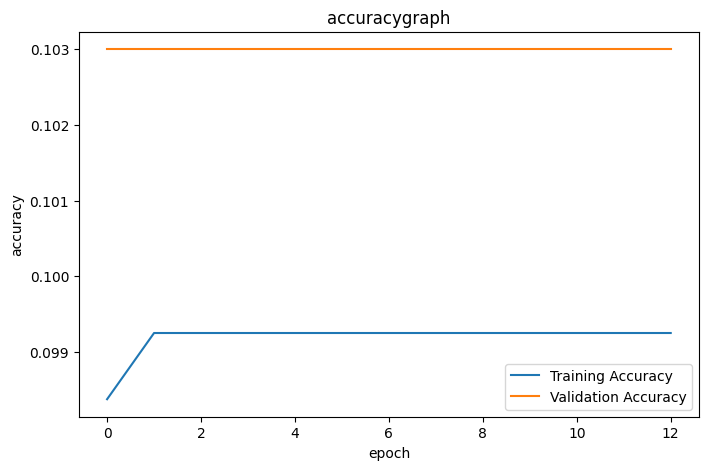

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('accuracygraph')
plt.legend()
plt.show()



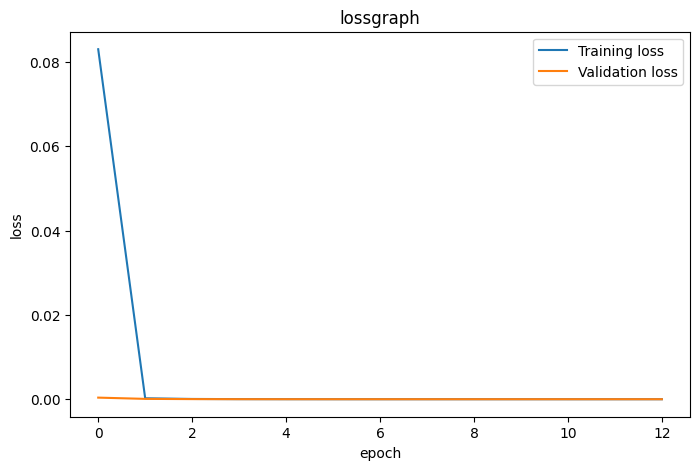

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('lossgraph')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0991 - loss: 620514.6875
loss 620514.6875
accuracy 0.09910000115633011
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 1000x1000 with 0 Axes>

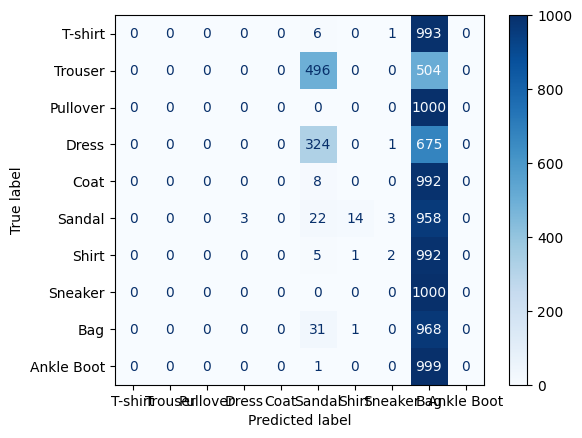

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print('loss',loss)
print('accuracy',accuracy)
prediction=model.predict(x_test)
prediction=np.argmax(prediction,axis=1)
cm=confusion_matrix(y_test,prediction)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
model.save('fashion_classifire.keras')
print('Model save succesfully')


Model save succesfully
